### Heart Disease Machine Learning Analysis

**Case Studies in Data Science – Individual Task 1**

This notebook analyses the UCI Heart Disease dataset using two classification algorithms:

- Decision Tree
- k-Nearest Neighbours (kNN)

The objective is to classify the presence or absence of heart disease and compare the effectiveness and insights provided by the two models.

Dataset source: https://archive.ics.uci.edu/dataset/45/heart+disease

In [2]:
# Install UCI package
!pip install ucimlrepo

## 1. Load Dataset

In [4]:
# Import libraries
import pandas as pd
import numpy as np

from ucimlrepo import fetch_ucirepo

# Load Heart Disease
heart_disease = fetch_ucirepo(id=45)

X_heart = heart_disease.data.features.copy()
y_heart = heart_disease.data.targets.copy()

print("Feature shape:", X_heart.shape)
print("Target shape:", y_heart.shape)

Feature shape: (303, 13)
Target shape: (303, 1)


## 2. Data Inspection

In [6]:
# Inspect the actual dataset
print("Heart Disease Features:")
display(X_heart.head())

print("\nTarget:")
display(y_heart.head())

# column names and data types
print("Column names:")
print(X_heart.columns.tolist())

print("\nData types:")
print(X_heart.dtypes)

Heart Disease Features:


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
0,63,1,1,145,233,1,2,150,0,2.3,3,0.0,6.0
1,67,1,4,160,286,0,2,108,1,1.5,2,3.0,3.0
2,67,1,4,120,229,0,2,129,1,2.6,2,2.0,7.0
3,37,1,3,130,250,0,0,187,0,3.5,3,0.0,3.0
4,41,0,2,130,204,0,2,172,0,1.4,1,0.0,3.0



Target:


,num
0,0
1,2
2,1
3,0
4,0


Column names:
['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal']

Data types:
age           int64
sex           int64
cp            int64
trestbps      int64
chol          int64
fbs           int64
restecg       int64
thalach       int64
exang         int64
oldpeak     float64
slope         int64
ca          float64
thal        float64
dtype: object


## 3. Data Quality Checks

In [8]:
# Missing values
print("Missing values:")
print(X_heart.isnull().sum())

print("\nTotal missing values:")
print(X_heart.isnull().sum().sum())

# Duplicates
heart_df = pd.concat([X_heart, y_heart], axis=1)

print("Dataset shape:", heart_df.shape)

print("Duplicate rows:")
print(heart_df.duplicated().sum())

Missing values:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          4
thal        2
dtype: int64

Total missing values:
6
Dataset shape: (303, 14)
Duplicate rows:
0


## 4. Target Preparation

The original `num` target ranges from 0 to 4. For this analysis it is converted into a binary classification target:

- 0 = No heart disease
- 1 = Heart disease present (`num` > 0)

In [10]:
# Examine the target
print("Original target distribution:")
print(y_heart['num'].value_counts().sort_index())

# Convert target to binary
y_heart_binary = (y_heart['num'] > 0).astype(int)

print("\nBinary target distribution:")
print(y_heart_binary.value_counts())

print("\nBinary target percentages:")
print((y_heart_binary.value_counts(normalize=True) * 100).round(2))

Original target distribution:
num
0    164
1     55
2     36
3     35
4     13
Name: count, dtype: int64

Binary target distribution:
num
0    164
1    139
Name: count, dtype: int64

Binary target percentages:
num
0    54.13
1    45.87
Name: proportion, dtype: float64


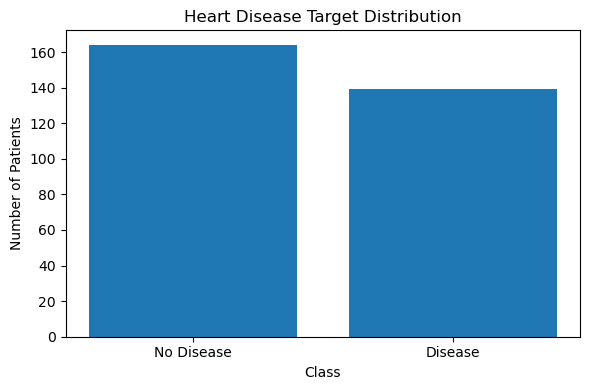

In [11]:
# Heart Disease target distribution

import matplotlib.pyplot as plt

counts = y_heart_binary.value_counts().sort_index()

plt.figure(figsize=(6, 4))
plt.bar(['No Disease', 'Disease'], counts.values)

plt.title('Heart Disease Target Distribution')
plt.ylabel('Number of Patients')
plt.xlabel('Class')

plt.tight_layout()
plt.show()

## 5. Leakage-Safe Preprocessing

The dataset is split before preprocessing. Numerical missing values are imputed using the training-set median and numerical variables are standardised. Categorical variables are imputed using the most frequent value and one-hot encoded.

This pipeline prevents information from the test set influencing preprocessing.

In [13]:
# Leakage-proof preprocessing

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

# Split data BEFORE preprocessing
X_train, X_test, y_train, y_test = train_test_split(
    X_heart, y_heart_binary,
    test_size=0.2,
    random_state=42,
    stratify=y_heart_binary
)

# Define feature types
numeric_features = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']

categorical_features = [
    'sex', 'cp', 'fbs', 'restecg',
    'exang', 'slope', 'ca', 'thal'
]

# Preprocessing
numeric_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer([
    ('num', numeric_transformer, numeric_features),
    ('cat', categorical_transformer, categorical_features)
])

print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)
print("Preprocessing pipeline ready.")

Training set: (242, 13)
Testing set: (61, 13)
Preprocessing pipeline ready.


## 6. Model 1 – Decision Tree

In [15]:
# Heart Disease Model 1: Decision Tree

from sklearn.tree import DecisionTreeClassifier
from sklearn.pipeline import Pipeline
from sklearn.base import clone
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix
)

# Create Decision Tree pipeline
dt_model = Pipeline([
    ('preprocessor', clonepreprocessor),
    ('classifier', DecisionTreeClassifier(
        random_state=42,
        max_depth=4
    ))
])

# Train the model
dt_model.fit(X_train, y_train)

# Predictions
y_pred_dt = dt_model.predict(X_test)
y_prob_dt = dt_model.predict_proba(X_test)[:, 1]

# Evaluation
print("Decision Tree Results")
print("Accuracy :", round(accuracy_score(y_test, y_pred_dt), 3))
print("Precision:", round(precision_score(y_test, y_pred_dt), 3))
print("Recall   :", round(recall_score(y_test, y_pred_dt), 3))
print("F1-score :", round(f1_score(y_test, y_pred_dt), 3))
print("ROC-AUC  :", round(roc_auc_score(y_test, y_prob_dt), 3))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_dt))

Decision Tree Results
Accuracy : 0.787
Precision: 0.742
Recall   : 0.821
F1-score : 0.78
ROC-AUC  : 0.86

Confusion Matrix:
[[25  8]
 [ 5 23]]


## 7. Model 2 – k-Nearest Neighbours

In [17]:
# Heart Disease Model 2: kNN

from sklearn.neighbors import KNeighborsClassifier

# Create kNN pipeline
knn_model = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', KNeighborsClassifier(n_neighbors=5))
])

# Train model
knn_model.fit(X_train, y_train)

# Predictions
y_pred_knn = knn_model.predict(X_test)
y_prob_knn = knn_model.predict_proba(X_test)[:, 1]

# Evaluation
print("kNN Results")
print("Accuracy :", round(accuracy_score(y_test, y_pred_knn), 3))
print("Precision:", round(precision_score(y_test, y_pred_knn), 3))
print("Recall   :", round(recall_score(y_test, y_pred_knn), 3))
print("F1-score :", round(f1_score(y_test, y_pred_knn), 3))
print("ROC-AUC  :", round(roc_auc_score(y_test, y_prob_knn), 3))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_knn))

kNN Results
Accuracy : 0.885
Precision: 0.862
Recall   : 0.893
F1-score : 0.877
ROC-AUC  : 0.953

Confusion Matrix:
[[29  4]
 [ 3 25]]


## 8. Model Comparison

In [19]:
# Compare Heart Disease models

import pandas as pd

results_heart = pd.DataFrame({
    'Model': ['Decision Tree', 'kNN'],
    'Accuracy': [
        accuracy_score(y_test, y_pred_dt),
        accuracy_score(y_test, y_pred_knn)
    ],
    'Precision': [
        precision_score(y_test, y_pred_dt),
        precision_score(y_test, y_pred_knn)
    ],
    'Recall': [
        recall_score(y_test, y_pred_dt),
        recall_score(y_test, y_pred_knn)
    ],
    'F1-score': [
        f1_score(y_test, y_pred_dt),
        f1_score(y_test, y_pred_knn)
    ],
    'ROC-AUC': [
        roc_auc_score(y_test, y_prob_dt),
        roc_auc_score(y_test, y_prob_knn)
    ]
})

print(results_heart.round(3))

           Model  Accuracy  Precision  Recall  F1-score  ROC-AUC
0  Decision Tree     0.787      0.742   0.821     0.780    0.860
1            kNN     0.885      0.862   0.893     0.877    0.953


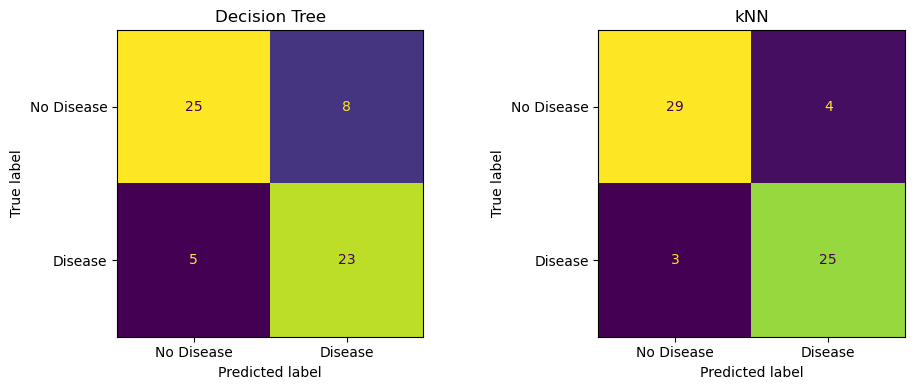

In [20]:
# Confusion matrices — Decision Tree and kNN

import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_dt,
    display_labels=['No Disease', 'Disease'],
    ax=axes[0],
    colorbar=False
)
axes[0].set_title('Decision Tree')

ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_knn,
    display_labels=['No Disease', 'Disease'],
    ax=axes[1],
    colorbar=False
)
axes[1].set_title('kNN')

plt.tight_layout()
plt.show()

## 9. Decision Tree Feature Importance

In [22]:
# Decision Tree feature importance

import pandas as pd

feature_names = dt_model.named_steps['preprocessor'].get_feature_names_out()

importance = dt_model.named_steps['classifier'].feature_importances_

feature_importance = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importance
}).sort_values('Importance', ascending=False)

print(feature_importance.head(10).round(3))

           Feature  Importance
25   cat__thal_3.0       0.442
10     cat__cp_4.0       0.160
21     cat__ca_0.0       0.139
4     num__oldpeak       0.078
2        num__chol       0.071
6     cat__sex_1.0       0.031
0         num__age       0.027
18  cat__slope_1.0       0.024
3     num__thalach       0.023
27   cat__thal_7.0       0.004


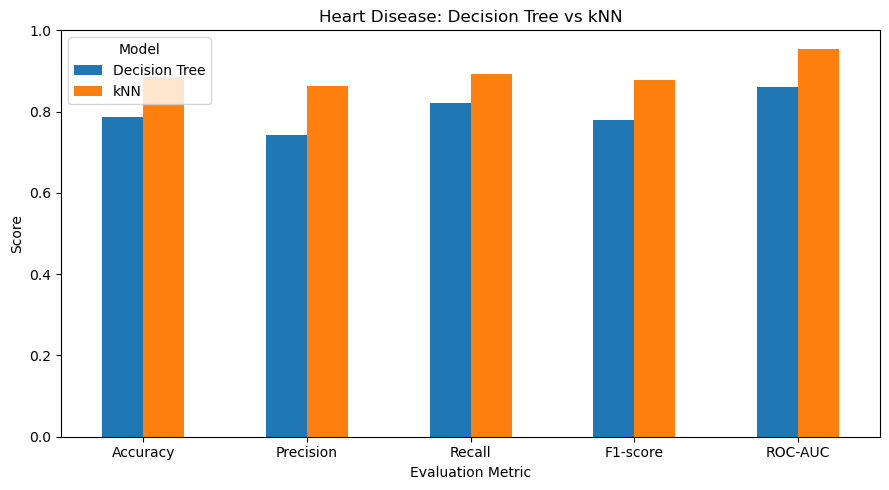

In [23]:
# Heart Disease Model Performance Comparison

import matplotlib.pyplot as plt

results_plot = results_heart.set_index('Model').T

results_plot.plot(kind='bar', figsize=(9, 5))

plt.title('Heart Disease: Decision Tree vs kNN')
plt.ylabel('Score')
plt.ylim(0, 1)
plt.xlabel('Evaluation Metric')
plt.xticks(rotation=0)
plt.legend(title='Model')

plt.tight_layout()

# Save graph for Overleaf
plt.savefig(
    'heart_model_comparison.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

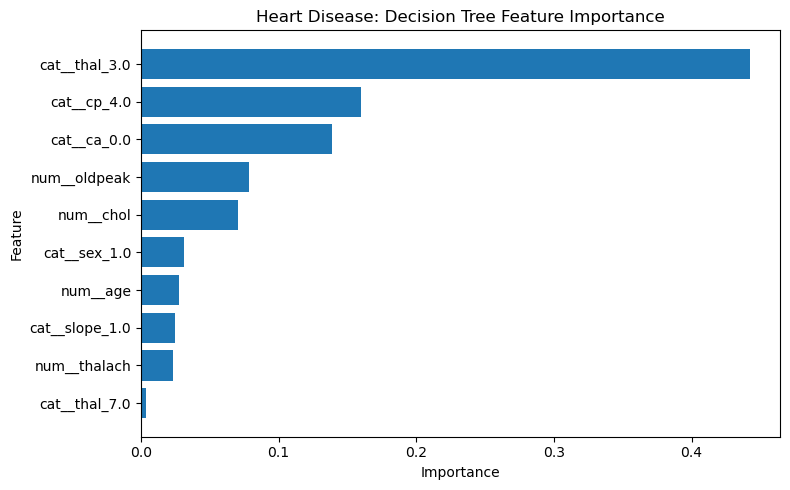

In [24]:
# Decision Tree Feature Importance

import matplotlib.pyplot as plt

top_features = feature_importance.head(10).sort_values(
    'Importance', ascending=True
)

plt.figure(figsize=(8, 5))
plt.barh(top_features['Feature'], top_features['Importance'])

plt.title('Heart Disease: Decision Tree Feature Importance')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

## 10. Key Findings

- kNN produced stronger test-set performance than the Decision Tree across all five evaluation metrics.
- kNN achieved 0.885 accuracy, 0.893 recall, 0.877 F1-score and 0.953 ROC-AUC.
- The Decision Tree achieved lower predictive performance but offered greater interpretability.
- The Decision Tree relied most strongly on thal-related information, chest-pain type, number of major vessels, ST depression and cholesterol.
- Feature importance represents predictive contribution within this fitted model and should not be interpreted as causation.
- The dataset contains only 303 observations, so results should be interpreted cautiously and should not be considered evidence of clinical deployment readiness.